In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
shark = pd.read_parquet('../catalogs/fibre_incomplete_mocks.parquet')

In [3]:
in_footprint1 = (shark.loc[:,'ra'] < 60)
in_footprint2 = (shark.loc[:,'ra'] > 60) & (shark.loc[:,'ra'] < 300)
in_footprint3 = (shark.loc[:,'ra'] > 300)
footprint = 1*in_footprint1 + 2*in_footprint2 + 3*in_footprint3
shark.loc[:,'footprint'] = footprint

In [7]:
shark.loc[:,'dz'] = shark.redshift_observed - shark.redshift_cosmological

In [8]:
fp1 = shark[shark.footprint==1]
fp2 = shark[shark.footprint==2]
fp3 = shark[shark.footprint==3]

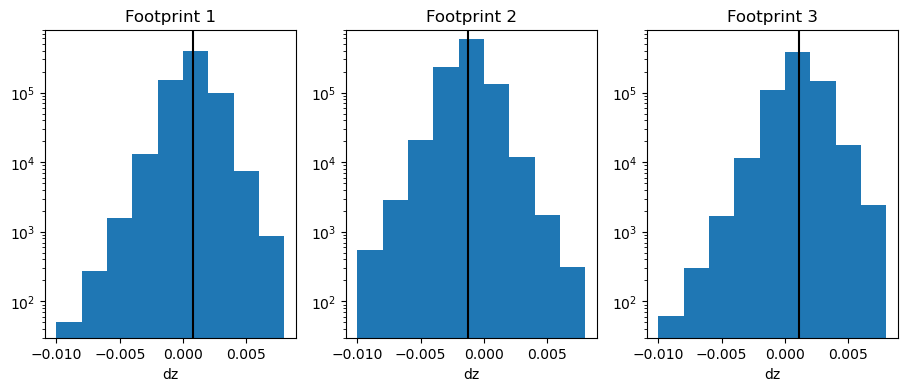

In [37]:
dzbin = np.arange(-0.01,0.01,0.002)

fig,axs=plt.subplots(ncols=3, figsize=(11,4))
medians=[]
for ii, df in enumerate([fp1,fp2,fp3]):
    axs[ii].hist(df.dz, bins=dzbin)
    med = df.dz.median()
    medians.append(med)
    axs[ii].axvline(med,color='k')
    axs[ii].set_ylim(3e1,8e5)
    axs[ii].set_yscale('log')
    axs[ii].set_xlabel('dz')
    axs[ii].set_title(f'Footprint {ii+1}')


for ax in axs:
    ax.set_yscale('log')
plt.show()

In [40]:
medians,print(np.average(medians))

0.0002318720022837321


([0.0007975399494171143, -0.0012550055980682373, 0.0011530816555023193], None)

In [32]:
sv2 = fp3[fp3.redshift_observed > 0.3]

0.001401782


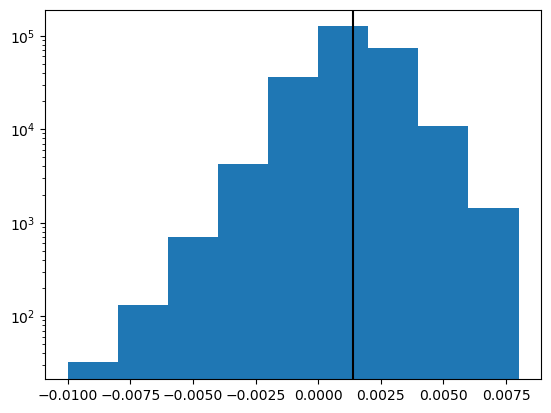

In [33]:
plt.figure()
plt.hist(sv2.dz, bins=dzbin)
med = np.median(sv2.dz)
print(med)
plt.axvline(med,color='k')
plt.yscale('log')
plt.show()

In [34]:
3e5 * med / (1+np.median(sv2.redshift_observed))

np.float32(278.33865)

In [36]:
shark.dz.median()

6.872043013572693e-05